# **Time Series Analysis**

## **Introduction to Time Series Analysis**

### **Time Series Data**

- Data collected over time

- Ordered sequentially (time index)

- Examples:
    - Stock prices
    - Weather data
    - Sensor readings
    - Economic indicators
    - Sales data
    - Website traffic
    - Social media activity
    - Health monitoring data, etc.....

[*********************100%***********************]  1 of 1 completed


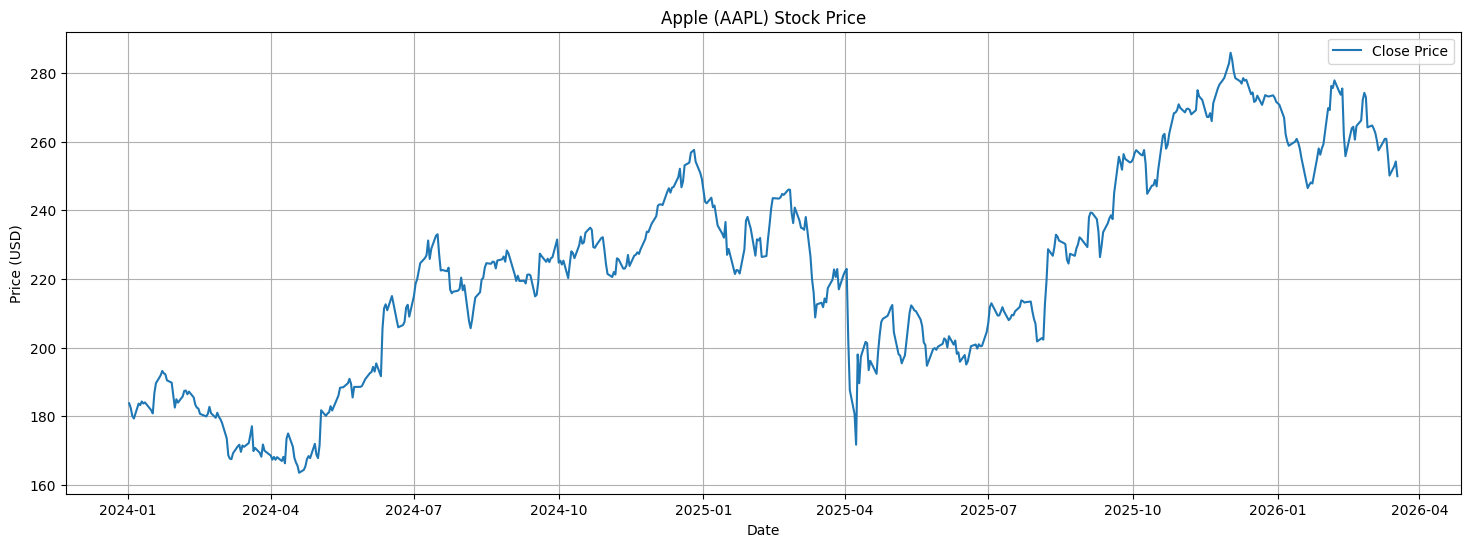

In [69]:
import yfinance as yf
import matplotlib.pyplot as plt

# Apple ticker
ticker = "AAPL"

# Download data
df = yf.download(ticker, start="2024-01-01", end="2026-03-19")


# Plot closing price
plt.figure(figsize=(18, 6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.title("Apple (AAPL) Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

### **Why time order matters**

In time series, time order matters because the **past influences the present, and the present influences the future.**

If we shuffle the observations, we lose trend, seasonality, and dependency structure.

- Time order matters because in time series, each observation depends on when it happened.

- If you ignore order, you destroy the main information in the data.

- Example: A stock price of ₹100 before ₹120 is different from ₹120 before ₹100.

#### **Why it matters**

Suppose these are monthly sales:

- 100, 120, 140, 160, 180

- This shows a clear upward trend.

If you shuffle them:

- 160, 100, 180, 120, 140

- the same values are present, but the trend disappears.

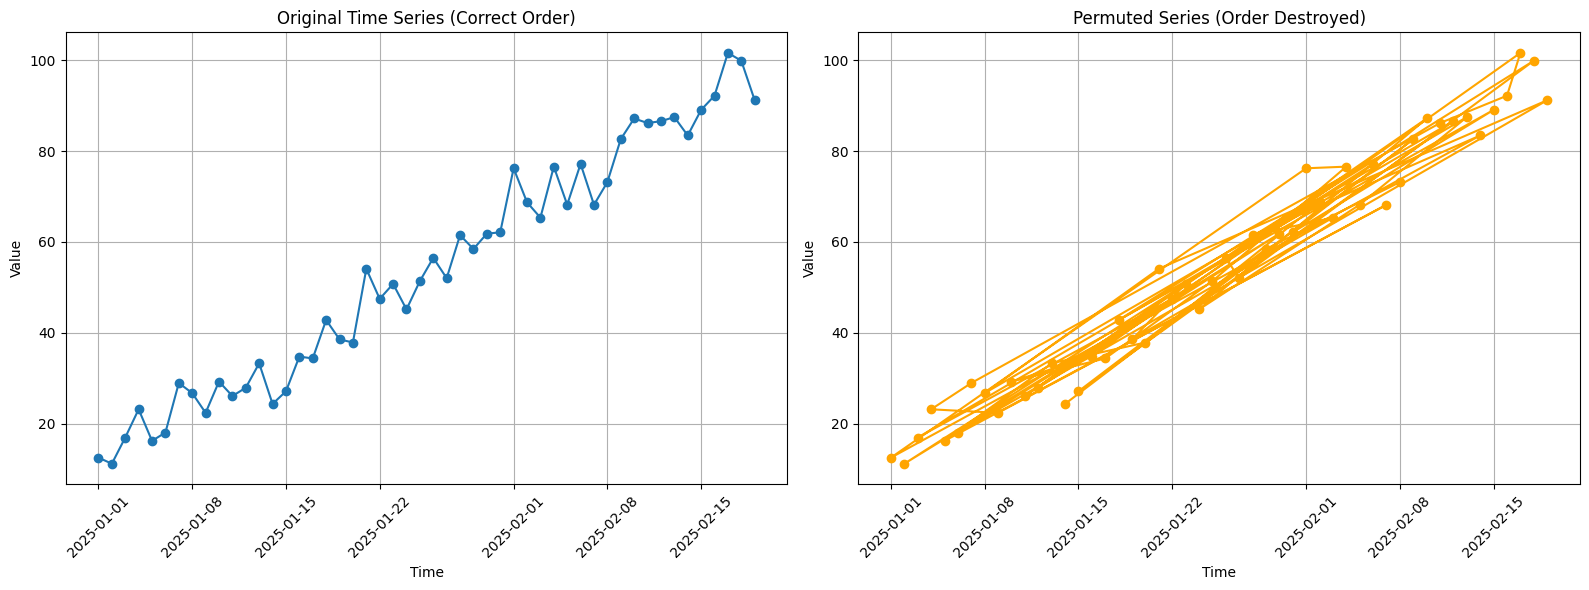

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create a time series (with trend)
np.random.seed(42)

n = 50
time = pd.date_range("2025-01-01", periods=n)

trend = np.linspace(10, 100, n)          # upward trend
noise = np.random.normal(0, 5, n)        # small noise
series = trend + noise

ts = pd.Series(series, index=time)

# Step 2: Create permuted (shuffled) version
permuted_ts = ts.sample(frac=1, random_state=42)

# Step 3: Plot both
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.plot(ts.index, ts.values, marker='o')
plt.title("Original Time Series (Correct Order)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid()

plt.subplot(1,2,2)
plt.plot(permuted_ts.index, permuted_ts.values, marker='o', color='orange')
plt.title("Permuted Series (Order Destroyed)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

### **Key Characteristics**


- **Trend**
    - Upward or downward movement
    - Example: Stock market movement
    - Example: Incresing population

- **Seasonality**
    - Repeating patterns at fixed intervals
    - Example: Ice Cream Sales in summer
    - Example: Festival sales (Diwali)

- **Cyclic**
    - Irregular, long-term
    - Example: Business cycles (boom → recession)
    - Example: Stock market trends (bull vs bear)

- **Residual/Noise**
    - Random fluctuations
    - Cannot be explained by trend, seasonality, or cyclic patterns.

[*********************100%***********************]  1 of 1 completed


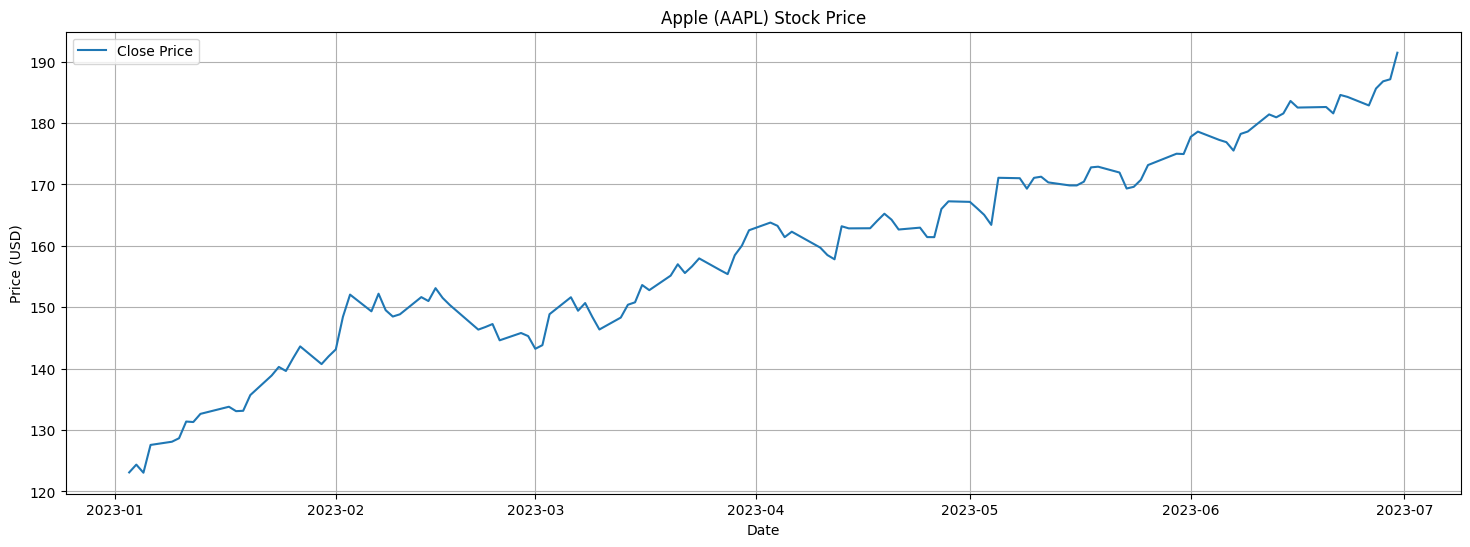

In [72]:
import yfinance as yf
import matplotlib.pyplot as plt

# Apple ticker
ticker = "AAPL"

# Download data
df = yf.download(ticker, start="2023-01-01", end="2023-07-01")

# Plot closing price
plt.figure(figsize=(18, 6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.title("Apple (AAPL) Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

### **Time Series Analysis**

Time Series Analysis is the process of analyzing data collected over time to:

- understand underlying patterns
- model temporal dependencies
- predict future values

**“Past influences present, and present influences future”**

### What can you do??

**Forecasting**

- Predict future values based on past data
- Examples:
    - Stock price prediction (Apple, NIFTY)
    - Weather forecasting
    - Demand forecasting (Amazon, Flipkart)

**Anomaly Detection**
- Identify unusual or unexpected patterns
- Examples:
    - Fraud detection in banking
    - Network intrusion detection
    - Sudden spike in ICU patients

## **Time Series Decomposition**

### What is Decomposition?

Time Series Decomposition is the process of breaking a time series into its main components:

- Trend
- Seasonality
- Residual (Noise)

**“Instead of analyzing everything together, we separate the patterns”**

### Why Decomposition?

**Break a complex signal into simpler parts**

- Understand hidden patterns
- Improve forecasting accuracy
- Identify noise/anomalies
- Simplify complex data


<img src="image/decompose-time-series.png" width="800">

### **Types of Decomposition Models**

#### **Additive Model**

$Y_t = T_t + S_t + R_t$

Used when variations are constant

Example: Temperature data



#### **Multiplicative Model**

$Y_t = T_t \times S_t \times R_t$

- Used when variation increases with time

- Example: Stock prices, sales growth


**Example: Additive**

- Seasonal values = fixed (-20, +30, +50)
- Fluctuations remain same height
- Independent of trend

Seasonal impact = constant shift
- Good for:
    - Temperature
    - Electricity baseline demand

| Month   | Trend (T) | Seasonality (S) | Residual (R) | Observed (Y = T + S + R) |
|--------|----------|----------------|-------------|--------------------------|
| Jan Y1 | 100      | -20            | +5          | 85                       |
| Jun Y1 | 150      | +30            | -10         | 170                      |
| Dec Y1 | 200      | +50            | +5          | 255                      |
| Jan Y2 | 220      | -20            | +2          | 202                      |
| Jun Y2 | 260      | +30            | -5          | 285                      |
| Dec Y2 | 300      | +50            | +8          | 358                      |
| Jan Y3 | 320      | -20            | -3          | 297                      |

    Month  Trend  Seasonality  Residual  Observed
0  Jan Y1    100          -20         5        85
1  Jun Y1    150           30       -10       170
2  Dec Y1    200           50         5       255
3  Jan Y2    220          -20         2       202
4  Jun Y2    260           30        -5       285
5  Dec Y2    300           50         8       358
6  Jan Y3    320          -20        -3       297


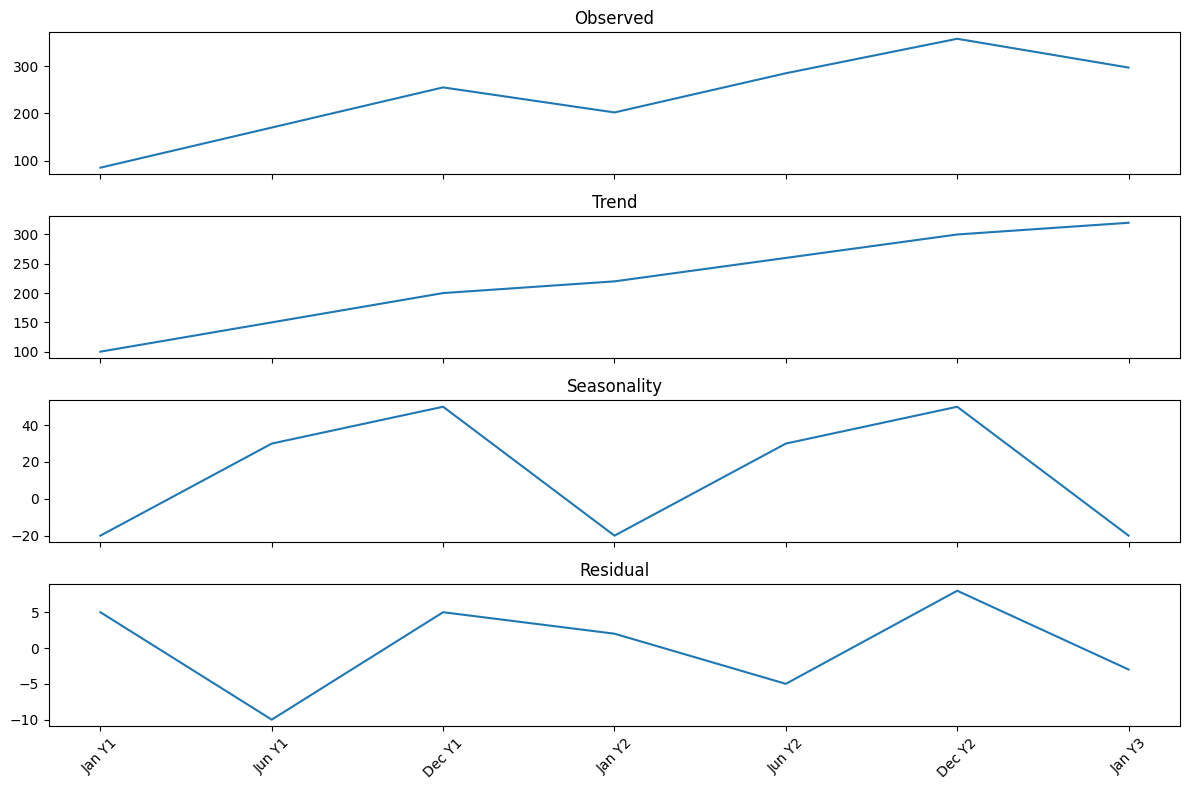

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
months = ["Jan Y1", "Jun Y1", "Dec Y1",
          "Jan Y2", "Jun Y2", "Dec Y2",
          "Jan Y3"]

trend = [100, 150, 200, 220, 260, 300, 320]
seasonality = [-20, 30, 50, -20, 30, 50, -20]
residual = [5, -10, 5, 2, -5, 8, -3]

observed = [t + s + r for t, s, r in zip(trend, seasonality, residual)]

df_add = pd.DataFrame({
    "Month": months,
    "Trend": trend,
    "Seasonality": seasonality,
    "Residual": residual,
    "Observed": observed
})

print(df_add)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12,8), sharex=True)

axes[0].plot(df_add["Observed"])
axes[0].set_title("Observed")

axes[1].plot(df_add["Trend"])
axes[1].set_title("Trend")

axes[2].plot(df_add["Seasonality"])
axes[2].set_title("Seasonality")

axes[3].plot(df_add["Residual"])
axes[3].set_title("Residual")

plt.xticks(range(len(months)), months, rotation=45)
plt.tight_layout()
plt.show()

**Example: Multiplicative**

- Seasonal effect scales with trend
- Fluctuations increase over time
- Bigger trend → bigger fluctuations

Seasonal effect = percentage-based
- Good for:
    - Sales
    - Stock prices
    - Revenue

    Month  Trend  Seasonality  Residual  Observed
0  Jan Y1    100          0.8       1.0      80.0
1  Jun Y1    150          1.2       1.0     180.0
2  Dec Y1    200          1.5       1.0     300.0
3  Jan Y2    220          0.8       1.0     176.0
4  Jun Y2    260          1.2       1.0     312.0
5  Dec Y2    300          1.5       1.0     450.0
6  Jan Y3    320          0.8       1.0     256.0


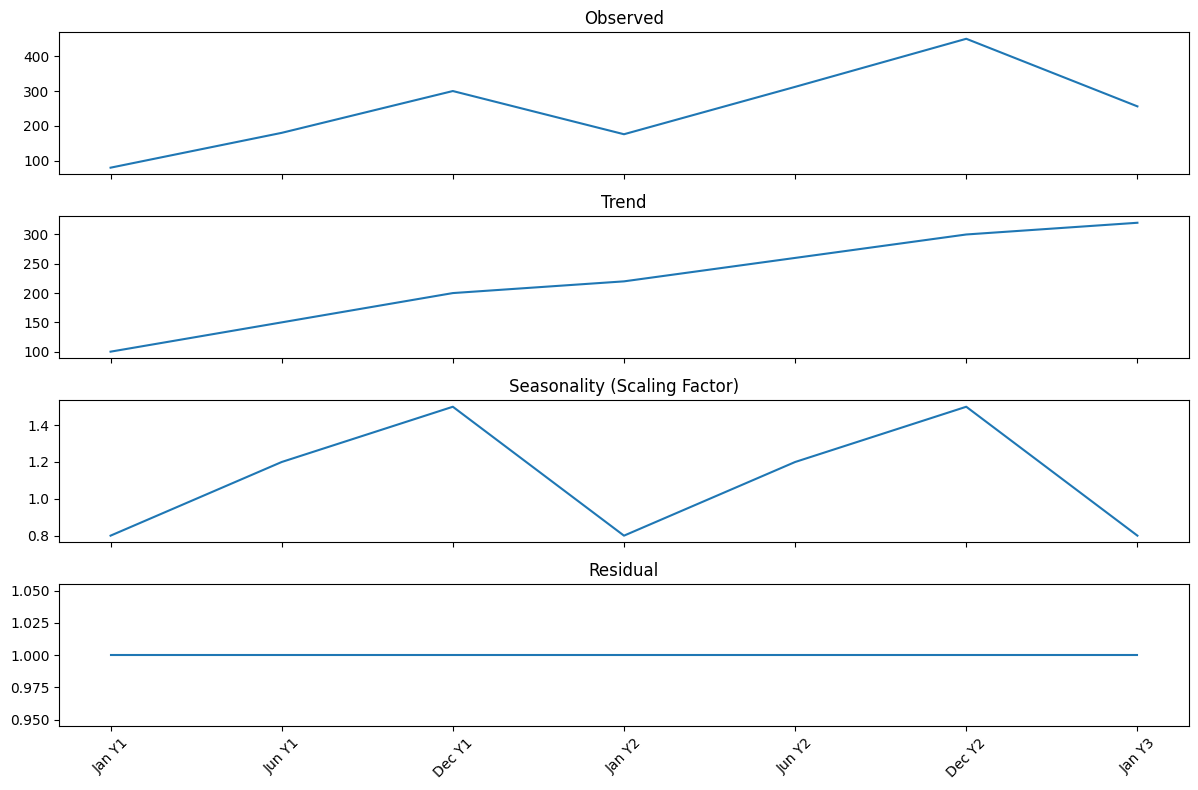

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
months = ["Jan Y1", "Jun Y1", "Dec Y1",
          "Jan Y2", "Jun Y2", "Dec Y2",
          "Jan Y3"]

trend = [100, 150, 200, 220, 260, 300, 320]
seasonality = [0.8, 1.2, 1.5, 0.8, 1.2, 1.5, 0.8]
residual = [1.0]*7

observed = [t * s * r for t, s, r in zip(trend, seasonality, residual)]

df_mul = pd.DataFrame({
    "Month": months,
    "Trend": trend,
    "Seasonality": seasonality,
    "Residual": residual,
    "Observed": observed
})

print(df_mul)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12,8), sharex=True)

axes[0].plot(df_mul["Observed"])
axes[0].set_title("Observed")

axes[1].plot(df_mul["Trend"])
axes[1].set_title("Trend")

axes[2].plot(df_mul["Seasonality"])
axes[2].set_title("Seasonality (Scaling Factor)")

axes[3].plot(df_mul["Residual"])
axes[3].set_title("Residual")

plt.xticks(range(len(months)), months, rotation=45)
plt.tight_layout()
plt.show()

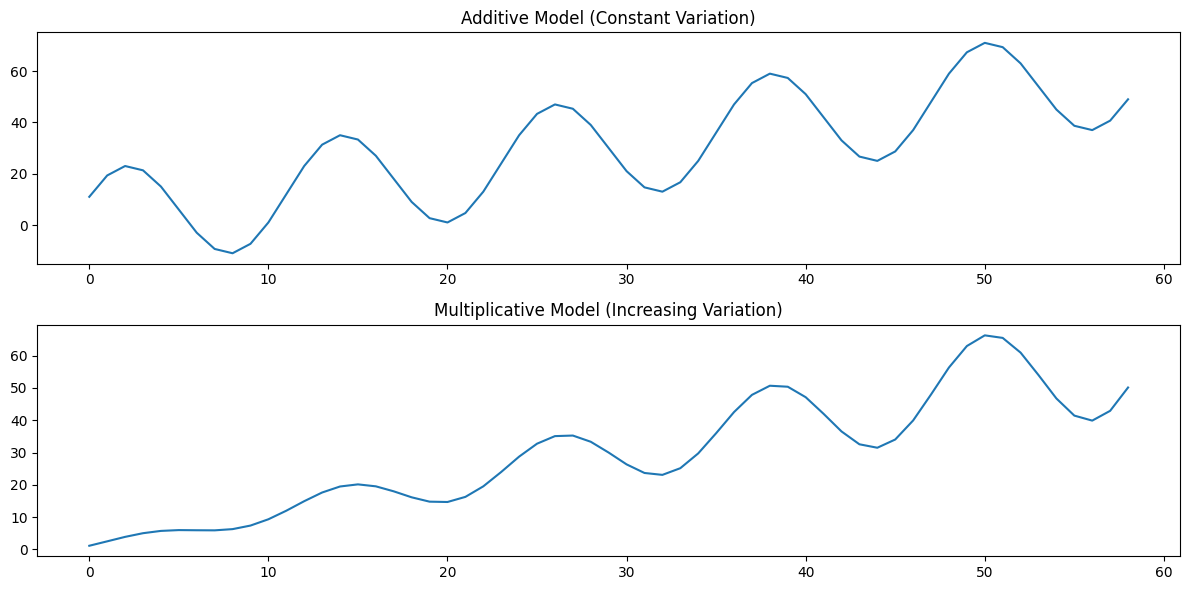

In [76]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(1, 60)

trend = t

# Additive
seasonal_add = 20 * np.sin(2 * np.pi * t / 12)
additive = trend + seasonal_add

# Multiplicative
seasonal_mul = 1 + 0.3 * np.sin(2 * np.pi * t / 12)
multiplicative = trend * seasonal_mul

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(additive)
plt.title("Additive Model (Constant Variation)")

plt.subplot(2,1,2)
plt.plot(multiplicative)
plt.title("Multiplicative Model (Increasing Variation)")

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


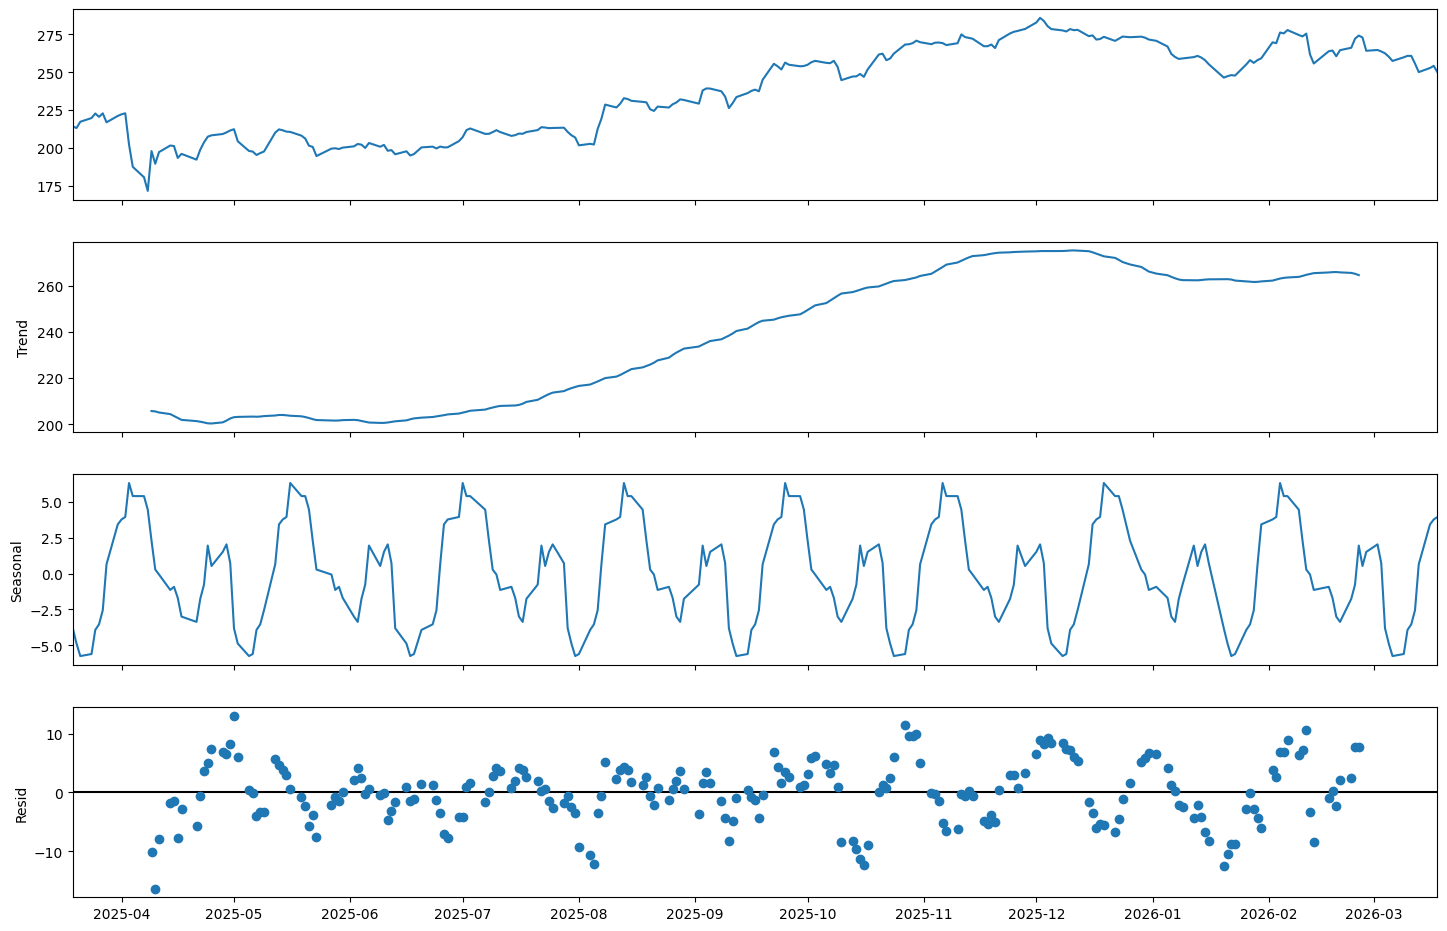

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose
import yfinance as yf
import matplotlib.pyplot as plt

df = yf.download("AAPL", period="1y")

result = seasonal_decompose(df["Close"], model='additive', period=30)
fig = result.plot()
fig.set_size_inches(16, 10)
plt.show()